<a href="https://colab.research.google.com/github/cjmunoz131/03MAIR---Algoritmos-de-Optimizacion/blob/main/Algoritmos_AG3_Plantilla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AG3 - Actividad Guiada 3
Nombre: Raul Reyero <br>
Link:   https://colab.research.google.com/drive/1BbplCdsVS79Y1FPYYBjdZ7m6noGisMKH <br>
Github: https://github.com/cjmunoz131/03MAIR---Algoritmos-de-Optimizacion
<br>




In [ ]:
import math

##Programación Dinámica. Viaje por el rio
* **Definición**: Es posible dividir el problema en subproblemas más pequeños, guardando las soluciones para ser utilizadas más adelante.
* **Características** que permiten identificar problemas aplicables:<br>
  -Es posible almacenar soluciones de los subproblemas para ser utilizados más adelante<br>
  -Debe verificar el principio de optimalidad de Bellman: “en una secuencia optima de decisiones, toda sub-secuencia también es óptima” (*)<br>
  -La necesidad de guardar la información acerca de las soluciones parciales unido a la recursividad provoca la necesidad de preocuparnos por la complejidad espacial (cuantos recursos de espacio usaremos)<br>

###Problema<br>
En un río hay **n** embarcaderos y debemos desplazarnos río abajo desde un embarcadero a otro. Cada embarcadero tiene precios diferentes para ir de un embarcadero a otro situado más abajo. Para ir del embarcadero i al j, puede ocurrir que sea más barato hacer un trasbordo por un embarcadero intermedio k. El problema consiste en determinar la combinación más barata.

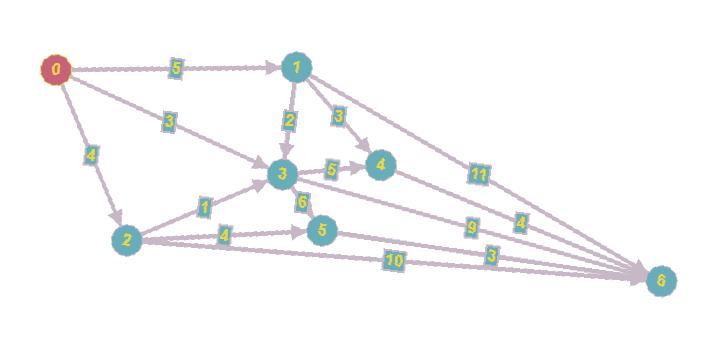

*Consideramos una tabla TARIFAS(i,j) para almacenar todos los precios que nos ofrecen los embarcaderos.<br>
*Si no es posible ir desde i a j daremos un valor alto para garantizar que ese trayecto no se va a elegir en la ruta óptima(modelado habitual para restricciones)

In [ ]:
#Viaje por el rio - Programación dinámica
################################################################################

TARIFAS = [
[0,5,4,3,float("inf"),999,999],   #desde nodo 0
[999,0,999,2,3,999,11],  #desde nodo 1
[999,999, 0,1,999,4,10], #desde nodo 2
[999,999,999, 0,5,6,9],
[999,999, 999,999,0,999,4],
[999,999, 999,999,999,0,3],
[999,999,999,999,999,999,0]
]

#999 se puede sustituir por float("inf") del modulo math
TARIFAS

[[0, 5, 4, 3, inf, 999, 999],
 [999, 0, 999, 2, 3, 999, 11],
 [999, 999, 0, 1, 999, 4, 10],
 [999, 999, 999, 0, 5, 6, 9],
 [999, 999, 999, 999, 0, 999, 4],
 [999, 999, 999, 999, 999, 0, 3],
 [999, 999, 999, 999, 999, 999, 0]]

In [ ]:
#Calculo de la matriz de PRECIOS y RUTAS
#  PRECIOS - contiene la matriz del mejor precio para ir de un nodo a otro
#  RUTAS   - contiene los nodos intermedios para ir de un nodo a otro
################################################################
def Precios(TARIFAS):
################################################################
  #Total de Nodos
  N = len(TARIFAS[0])

  #Inicialización de la tabla de precios
  PRECIOS = [ [9999]*N for i in [9999]*N]  #n x n
  RUTA = [ [""]*N for i in [""]*N]

  #Se recorren todos los nodos con dos bucles(origen - destino)
  #  para ir construyendo la matriz de PRECIOS
  for i in range(N-1):
    for j in range(i+1, N):
      MIN = TARIFAS[i][j]
      RUTA[i][j] = i

      for k in range(i, j):
        if PRECIOS[i][k] + TARIFAS[k][j] < MIN:
            MIN = min(MIN, PRECIOS[i][k] + TARIFAS[k][j] )
            RUTA[i][j] = k
        PRECIOS[i][j] = MIN

  return PRECIOS,RUTA

In [ ]:
PRECIOS,RUTA = Precios(TARIFAS)
#print(PRECIOS[0][6])

print("PRECIOS")
for i in range(len(TARIFAS)):
  print(PRECIOS[i])

print("\nRUTA")
for i in range(len(TARIFAS)):
  print(RUTA[i])

PRECIOS
[9999, 5, 4, 3, 8, 8, 11]
[9999, 9999, 999, 2, 3, 8, 7]
[9999, 9999, 9999, 1, 6, 4, 7]
[9999, 9999, 9999, 9999, 5, 6, 9]
[9999, 9999, 9999, 9999, 9999, 999, 4]
[9999, 9999, 9999, 9999, 9999, 9999, 3]
[9999, 9999, 9999, 9999, 9999, 9999, 9999]

RUTA
['', 0, 0, 0, 1, 2, 5]
['', '', 1, 1, 1, 3, 4]
['', '', '', 2, 3, 2, 5]
['', '', '', '', 3, 3, 3]
['', '', '', '', '', 4, 4]
['', '', '', '', '', '', 5]
['', '', '', '', '', '', '']


In [ ]:
#Calculo de la ruta usando la matriz RUTA
def calcular_ruta(RUTA, desde, hasta):
  if desde == RUTA[desde][hasta]:
  #if desde == hasta:
    #print("Ir a :" + str(desde))
    return desde
  else:
    return str(calcular_ruta(RUTA, desde, RUTA[desde][hasta])) +  ',' + str(RUTA[desde][hasta])

print("\nLa ruta pasa por :")
print(calcular_ruta(RUTA, 0,6) )
print("Con valor" , PRECIOS[0][6])



La ruta pasa por :
0,2,5
Con valor 11


##Problema de Asignacion de tarea

In [1]:
import time

# Decorador para medir el tiempo de ejecución
def medir_tiempo(func):
    def wrapper(*args, **kwargs):
        inicio = time.perf_counter()
        resultado = func(*args, **kwargs)
        fin = time.perf_counter()
        print(f"Tiempo de ejecución de '{func.__name__}': {fin - inicio:.6f} segundos")
        return resultado
    return wrapper

In [2]:
#Asignacion de tareas - Ramificación y Poda
################################################################################
#    T A R E A
#   A
#   G
#   E
#   N
#   T
#   E

COSTES=[[11,12,18,40],
        [14,15,13,22],
        [11,17,19,23],
        [17,14,20,28]]


In [53]:
#Calculo del valor de una solucion parcial
def valor(S,COSTES):
  VALOR = 0
  for i in range(len(S)):
    VALOR += COSTES[i][S[i]]
  return VALOR



valor((0, 2, 3, 1  ),COSTES)

61

In [92]:
#Coste inferior para soluciones parciales
#  (1,3,) Se asigna la tarea 1 al agente 0 y la tarea 3 al agente 1

def CI(S,COSTES):
  VALOR = 0
  NO_ASIGNADOS = list()
  #Valores establecidos
#  for i in range(len(S)):
#    VALOR += COSTES[i][S[i]]

  for i in range(len(COSTES)):
    if i < len(S):
      VALOR += COSTES[i][S[i]]
    if i not in S:
      NO_ASIGNADOS.append(i)

  #Estimacion
#  for i in range( len(S), len(COSTES)   ):
#    VALOR += min( [ COSTES[i][j] for j in range(len(S), len(COSTES))  ])
#  return VALOR
  for i in range( len(S), len(COSTES)):
    VALOR += min( [COSTES[i][NO_ASIGNADOS[j]] for j in range(len(NO_ASIGNADOS))])
  return VALOR

def CS(S,COSTES):
  VALOR = 0
  NO_ASIGNADOS = list()
  #Valores establecidos
#  for i in range(len(S)):
#    VALOR += COSTES[i][S[i]]

  for i in range(len(COSTES)):
    if i < len(S):
      VALOR += COSTES[i][S[i]]
    if i not in S:
      NO_ASIGNADOS.append(i)

  #Estimacion
#  for i in range( len(S), len(COSTES)   ):
#    VALOR += max( [ COSTES[i][j] for j in range(len(S), len(COSTES))  ])
#  return VALOR
  for i in range( len(S), len(COSTES)   ):
    VALOR += max( [ COSTES[i][j] for j in range(NO_ASIGNADOS)])
  return VALOR

CI((0,1),COSTES)

65

In [93]:
#Genera tantos hijos como como posibilidades haya para la siguiente elemento de la tupla
#(0,) -> (0,1), (0,2), (0,3)
def crear_hijos(NODO, N):
  HIJOS = []
  for i in range(N ):
    if i not in NODO:
      HIJOS.append({'s':NODO +(i,)    })
  return HIJOS

In [94]:
crear_hijos((0,) , 4)

[{'s': (0, 1)}, {'s': (0, 2)}, {'s': (0, 3)}]

In [114]:
@medir_tiempo
def ramificacion_y_poda(COSTES):
#Construccion iterativa de soluciones(arbol). En cada etapa asignamos un agente(ramas).
#Nodos del grafo  { s:(1,2),CI:3,CS:5  }
  #print(COSTES)
  DIMENSION = len(COSTES)
  MEJOR_SOLUCION=tuple( i for i in range(len(COSTES)) )
  CotaSup = valor(MEJOR_SOLUCION,COSTES)
  #print("Cota Superior:", CotaSup)

  NODOS=[]
  NODOS.append({'s':(), 'ci':CI((),COSTES)    } )

  iteracion = 0

  while( len(NODOS) > 0):
    iteracion +=1

    nodo_prometedor = [ min(NODOS, key=lambda x:x['ci']) ][0]['s']
   #print("Nodo prometedor:", nodo_prometedor)

    #Ramificacion
    #Se generan los hijos
    HIJOS =[ {'s':x['s'], 'ci':CI(x['s'], COSTES)   } for x in crear_hijos(nodo_prometedor, DIMENSION) ]
    #print("\n********Hijos generados:",  HIJOS )
    #Revisamos la cota superior y nos quedamos con la mejor solucion si llegamos a una solucion final
    NODO_FINAL = [x for x in HIJOS if len(x['s']) == DIMENSION  ]
    if len(NODO_FINAL) >0:
      #print("\n********Soluciones:",  [x for x in HIJOS if len(x['s']) == DIMENSION  ] )
      if NODO_FINAL[0]['ci'] < CotaSup:
        CotaSup = NODO_FINAL[0]['ci']
        MEJOR_SOLUCION = NODO_FINAL

    #Poda
    HIJOS = [x for x in HIJOS if x['ci'] < CotaSup   ]

    #Añadimos los hijos
    NODOS.extend(HIJOS)

    #Eliminamos el nodo ramificado
    NODOS =  [  x for x in NODOS if x['s'] != nodo_prometedor    ]
    #print("NODOS despues podar el nodo ramificado:", NODOS)

  print("La solucion final es:" ,MEJOR_SOLUCION , " en " , iteracion , " iteraciones" , " para dimension: " ,DIMENSION  )



ramificacion_y_poda(COSTES)

La solucion final es: [{'s': (0, 2, 3, 1), 'ci': 61}]  en  17  iteraciones  para dimension:  4
Tiempo de ejecución de 'ramificacion_y_poda': 0.001926 segundos


###Asignación de tareas - desarrollo por fuerza bruta

In [96]:
import math
import itertools

@medir_tiempo
def fuerza_bruta(COSTES):
  mejor_valor = math.inf
  mejor_solucion = ()
  N = len(COSTES)
  espacio_soluciones = list(itertools.permutations(range(N),N))
  for tupla in espacio_soluciones:
    valor_tmp = valor(tupla,COSTES)
    if valor_tmp < mejor_valor:
      mejor_valor = valor_tmp
      mejor_solucion = tupla
  print("La solucion final es:" ,mejor_solucion , " con mejor valor de " , mejor_valor , " para dimension: " ,N)

In [97]:
fuerza_bruta(COSTES)

La solucion final es: (0, 2, 3, 1)  con mejor valor de  61  para dimension:  4
Tiempo de ejecución de 'fuerza_bruta': 0.000710 segundos


###Comparación de algoritmos - Fuerza Bruta y Ramifición y poda (Asignación de tareas)

In [105]:
import numpy as np
lst_costes = list()
for i in range (5,8):
  lst_costes.append((np.random.randint(0, 100, (i, i))).tolist())
print(lst_costes)

for costes in lst_costes:
  fuerza_bruta(costes)
  ramificacion_y_poda(costes)

[[[67, 46, 5, 88, 30], [45, 68, 83, 74, 65], [0, 40, 42, 97, 46], [74, 59, 18, 24, 90], [81, 28, 92, 77, 67]], [[16, 5, 47, 17, 82, 94], [31, 73, 99, 4, 93, 55], [39, 39, 92, 20, 78, 77], [61, 63, 0, 78, 6, 58], [80, 45, 89, 68, 77, 26], [95, 17, 3, 14, 39, 38]], [[67, 77, 88, 57, 22, 41, 68], [70, 24, 86, 41, 66, 31, 33], [83, 88, 3, 41, 35, 74, 91], [86, 52, 87, 4, 70, 49, 14], [81, 86, 10, 80, 57, 13, 66], [72, 57, 81, 29, 34, 87, 76], [37, 99, 19, 57, 34, 59, 84]]]
La solucion final es: (2, 4, 0, 3, 1)  con mejor valor de  122  para dimension:  5
Tiempo de ejecución de 'fuerza_bruta': 0.000221 segundos
La solucion final es: [{'s': (2, 4, 0, 3, 1), 'ci': 122}]  en  19  iteraciones  para dimension:  5
Tiempo de ejecución de 'ramificacion_y_poda': 0.000945 segundos
La solucion final es: (1, 3, 0, 4, 5, 2)  con mejor valor de  83  para dimension:  6
Tiempo de ejecución de 'fuerza_bruta': 0.001089 segundos
La solucion final es: [{'s': (1, 3, 0, 4, 5, 2), 'ci': 83}]  en  26  iteraciones 

###¿A partir de que dimensión se nota una ineficiencia del algoritmo de fuerza bruta?

In [ ]:
import numpy as np
lst_costes = list()
for i in range (8,12):
  lst_costes.append((np.random.randint(0, 30, (i, i))).tolist())
print(lst_costes)

for costes in lst_costes:
  fuerza_bruta(costes)
#  ramificacion_y_poda(costes)


[[[6, 7, 21, 8, 11, 5, 22, 10], [21, 22, 11, 3, 13, 5, 7, 22], [23, 9, 1, 27, 25, 22, 13, 3], [12, 5, 29, 3, 11, 28, 13, 23], [21, 6, 4, 10, 17, 1, 14, 26], [28, 7, 16, 19, 24, 13, 29, 10], [5, 20, 14, 29, 22, 2, 12, 29], [19, 25, 21, 24, 25, 28, 10, 9]], [[28, 2, 12, 23, 14, 28, 4, 3, 9], [22, 8, 21, 8, 4, 15, 2, 8, 0], [15, 4, 21, 22, 10, 19, 0, 28, 27], [7, 11, 19, 0, 23, 6, 28, 16, 24], [10, 15, 8, 23, 13, 5, 15, 4, 28], [27, 20, 20, 13, 23, 27, 23, 1, 6], [10, 29, 4, 12, 25, 29, 5, 7, 0], [6, 21, 6, 19, 14, 20, 22, 28, 7], [20, 22, 12, 25, 22, 15, 22, 15, 19]], [[0, 16, 21, 7, 20, 6, 24, 11, 20, 8], [0, 10, 17, 6, 8, 4, 9, 6, 1, 20], [11, 0, 24, 0, 18, 20, 24, 4, 1, 4], [25, 4, 27, 11, 6, 19, 18, 18, 26, 19], [26, 13, 28, 22, 1, 1, 11, 7, 15, 20], [19, 7, 23, 28, 8, 3, 11, 15, 23, 28], [9, 17, 15, 22, 15, 19, 7, 24, 18, 3], [20, 5, 18, 12, 25, 3, 29, 9, 11, 18], [12, 3, 1, 9, 6, 6, 8, 23, 7, 27], [11, 24, 27, 4, 5, 27, 4, 24, 29, 27]], [[14, 17, 21, 29, 20, 24, 9, 0, 29, 12, 7], [

Se observa que a partir de arreglos con dimensión 11 el algoritmo de fuerza bruta se empieza a demorar 46 segundos, esto porque debe realizar 11!= 39916800 iteraciones

###¿A partir de que dimensión se nota una ineficiencia del algoritmo de ramificación y poda?

In [110]:
import numpy as np
lst_costes = list()
for i in range (8,16):
  lst_costes.append((np.random.randint(0, 30, (i, i))).tolist())
print(lst_costes)

for costes in lst_costes:
  ramificacion_y_poda(costes)

[[[19, 11, 25, 13, 28, 7, 13, 23], [9, 17, 19, 22, 3, 27, 18, 8], [15, 5, 0, 25, 17, 7, 18, 23], [25, 5, 5, 6, 10, 2, 25, 10], [5, 21, 19, 11, 12, 14, 1, 1], [15, 14, 12, 1, 2, 14, 8, 13], [0, 29, 27, 18, 22, 4, 10, 11], [20, 27, 11, 20, 1, 15, 25, 14]], [[9, 28, 21, 14, 16, 4, 28, 15, 29], [10, 6, 9, 20, 3, 14, 19, 27, 7], [26, 14, 28, 28, 28, 14, 14, 22, 9], [28, 22, 23, 0, 21, 13, 4, 11, 25], [13, 2, 10, 14, 29, 8, 11, 12, 19], [23, 5, 10, 3, 20, 1, 6, 26, 15], [9, 28, 12, 7, 10, 25, 6, 19, 2], [6, 5, 18, 19, 9, 22, 12, 8, 20], [21, 14, 10, 27, 10, 5, 17, 3, 18]], [[3, 12, 25, 17, 14, 6, 0, 22, 0, 14], [7, 28, 20, 7, 7, 29, 27, 3, 24, 22], [17, 13, 29, 29, 13, 21, 14, 14, 25, 25], [9, 29, 8, 11, 26, 13, 12, 12, 29, 15], [3, 9, 14, 5, 26, 1, 4, 0, 2, 19], [23, 25, 1, 19, 26, 1, 8, 0, 15, 28], [22, 22, 21, 4, 18, 4, 13, 23, 10, 4], [2, 7, 11, 29, 13, 10, 1, 6, 19, 26], [1, 15, 21, 3, 19, 2, 21, 5, 24, 2], [6, 11, 11, 5, 2, 29, 18, 28, 6, 19]], [[11, 18, 26, 15, 21, 25, 14, 8, 25, 25, 

Se observa que a partir de arreglos con dimensión 15 el algoritmo de ramificación y poda se empieza a demorar 22 segundos.

##Descenso del gradiente

In [ ]:
import math                      #Funciones matematicas
import matplotlib.pyplot as plt  #Generacion de gráficos (otra opcion seaborn)
import numpy as np               #Tratamiento matriz N-dimensionales y otras (fundamental!)
#import scipy as sc

import random

Vamos a buscar el minimo de la funcion paraboloide por le metodo del descenso del gradiente : $$f(x) =  x² + y²$$

Obviamente se encuentra en (x,y)=(0,0) pero probaremos como llegamos a él a través del descenso del gradiante.

In [ ]:
#Definimos la funcion(f) y el gradiente(df)
#Paraboloide
f  = lambda X:      X[0]**2 + X[1]**2    #Funcion
df = lambda X: [2*X[0] , 2*X[1]]         #Gradiente

df([1,2])

[2, 4]

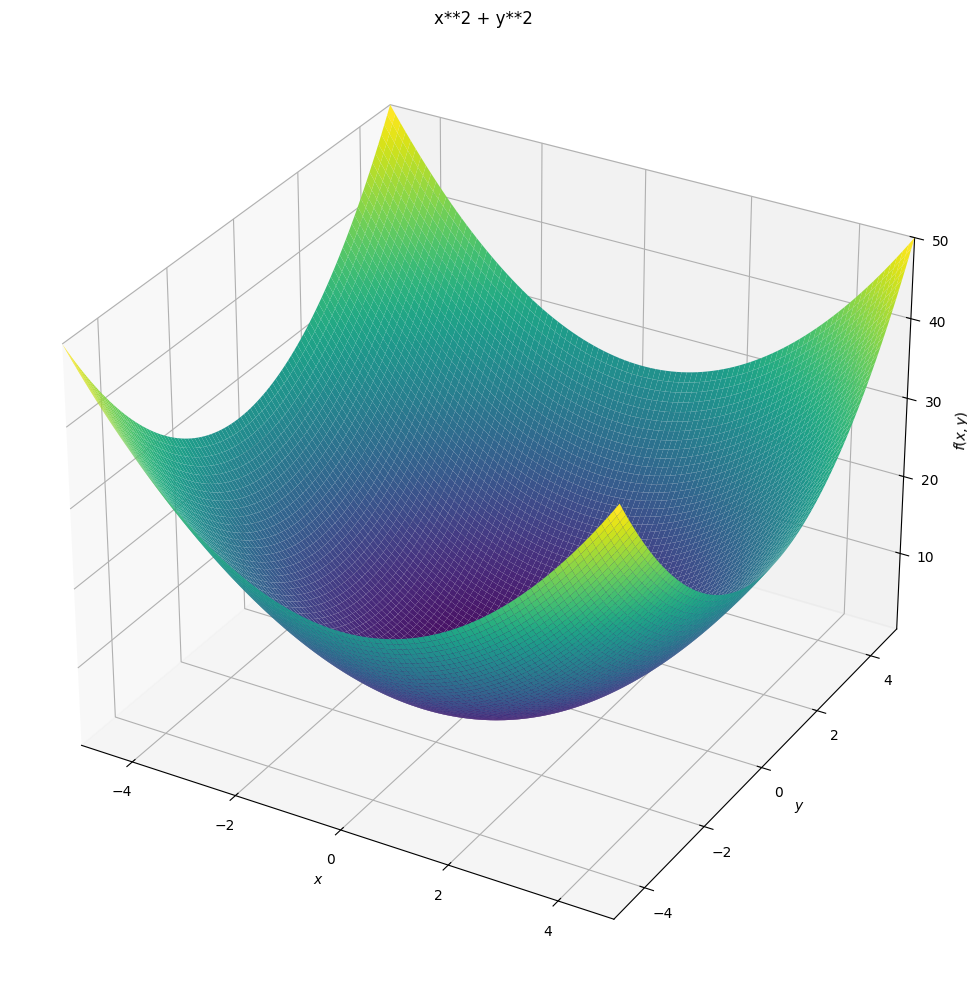

In [ ]:
from sympy import symbols
from sympy.plotting import plot
from sympy.plotting import plot3d
x,y = symbols('x y')
plot3d(x**2 + y**2,
       (x,-5,5),(y,-5,5),
       title='x**2 + y**2',
       size=(10,10))

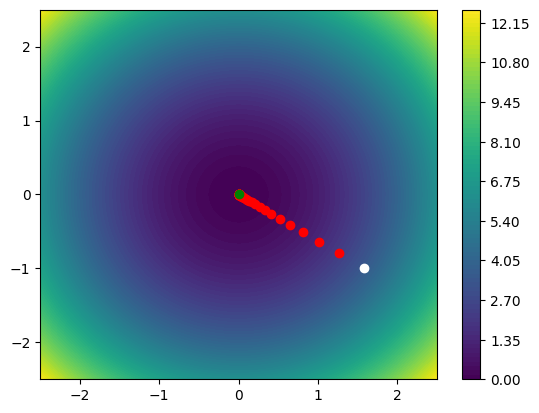

Solucion: [2.2506935405412444e-05, -1.419544189460296e-05] 7.08072711926457e-10


In [ ]:
#Prepara los datos para dibujar mapa de niveles de Z
resolucion = 100
rango=2.5

X=np.linspace(-rango,rango,resolucion)
Y=np.linspace(-rango,rango,resolucion)
Z=np.zeros((resolucion,resolucion))
for ix,x in enumerate(X):
  for iy,y in enumerate(Y):
    Z[iy,ix] = f([x,y])

#Pinta el mapa de niveles de Z
plt.contourf(X,Y,Z,resolucion)
plt.colorbar()

#Generamos un punto aleatorio inicial y pintamos de blanco
P=[random.uniform(-2,2  ),random.uniform(-2,2 ) ]
plt.plot(P[0],P[1],"o",c="white")

#Tasa de aprendizaje. Fija. Sería más efectivo reducirlo a medida que nos acercamos.
TA=.1

#Iteraciones:500
for _ in range(50):
  grad = df(P)
  #print(P,grad)
  P[0],P[1] = P[0] - TA*grad[0] , P[1] - TA*grad[1]
  plt.plot(P[0],P[1],"o",c="red")

#Dibujamos el punto final y pintamos de verde
plt.plot(P[0],P[1],"o",c="green")
plt.show()
print("Solucion:" , P , f(P))


**¿Te atreves a optimizar la función?:**

$$f(x)=sin(1/2 * x^2 - 1/4 * y^2 + 3) * cos(2*x + 1 - e^y)$$
<br>
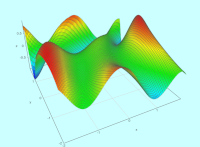


In [ ]:
#Definimos la funcion f y la df analiticamente
import math
import numpy as np
f= lambda X: math.sin(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3) *math.cos(2*X[0] + 1 - math.exp(X[1]) )
df = lambda X: [X[0] * math.cos(0.5 * X[0]**2 - 0.25 * X[1]**2 + 3) * math.cos(2 * X[0] + 1 - math.exp(X[1])) - 2 * X[0] * math.sin(0.5 * X[0]**2 - 0.25 * X[1]**2 +3) * math.sin(2 * X[0] + 1 - math.exp(X[1])) , - 0.5 * X[1] * math.cos(2 * X[0] + 1 - math.exp(X[1])) * math.cos(0.5 * X[0]**2 - 0.25 * X[1]**2 + 3) + math.exp(X[1]) * math.sin(0.5 * X[0]**2 - 0.25 * X[1]**2 +3) * math.sin(2 * X[0] + 1 - math.exp(X[1]))]

In [ ]:
def func(x, y):
    return np.sin(0.5 * x**2 - 0.25 * y**2 + 3) * np.cos(2 * x + 1 - np.exp(y))

In [ ]:
def dfunc(x,y):
  grad =[x * np.cos(0.5 * x**2 - 0.25 * y**2 + 3) * np.cos(2 * x + 1 - np.exp(y)) - 2 * x * np.sin(0.5 * x**2 - 0.25 * y**2 +3) * np.sin(2 * x + 1 - np.exp(y)) , - 0.5 * y * np.cos(2 * x + 1 - np.exp(y)) * np.cos(0.5 * x**2 - 0.25 * y**2 + 3) + np.exp(y) * np.sin(0.5 * x**2 - 0.25 * y**2 +3) * np.sin(2 * x + 1 - np.exp(y))]
  return grad

In [ ]:
def dfuncaprox(PUNTO):
  h = 0.0001
  T = np.copy(PUNTO).astype(float)
  grad = np.zeros(2)
  for it, th in enumerate(PUNTO):
    print(T[it])
    T[it] = T[it] + h
    #T[it] = float(T[it] + h )
    print(T[it])
    print(f"El nuevo punto es{T}")
    grad[it] = (f(T)-f(PUNTO)) / h
  return grad

In [ ]:
df([1,2])

[-0.8803745550791662, 3.9384502467765357]

In [ ]:
dfunc(1,2)

[-0.8803745550791662, 3.9384502467765357]

In [ ]:
dfuncaprox([1,2])

1.0
1.0001
El nuevo punto es[1.0001 2.    ]
2.0
2.0001
El nuevo punto es[1.0001 2.0001]


array([-0.88016235,  3.05856771])

###Desarrollamos la gráfica en 3D de la función $$f(x)=sin(1/2 * x^2 - 1/4 * y^2 + 3) * cos(2*x + 1 - e^y)$$

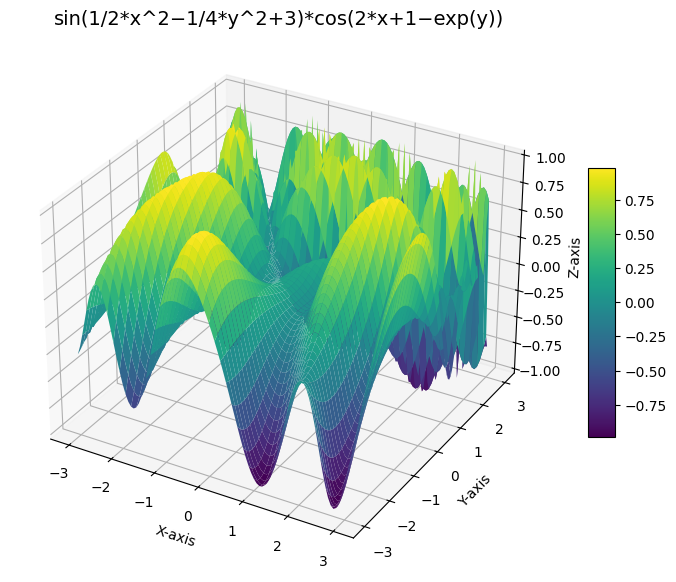

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

resolucion = 100
rango = 3

x = np.linspace(-rango, rango, resolucion)
y = np.linspace(-rango, rango, resolucion)


X, Y = np.meshgrid(x, y)
Z = func(X, Y)


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')


ax.set_title("sin(1/2*x^2−1/4*y^2+3)*cos(2*x+1−exp(y))", fontsize=14)
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
fig.colorbar(surf, shrink=0.5, aspect=10)

plt.show()

###Desarrollo del descenso de la gradiente de la función con curvas de nivel, TA=0.005 y 500 iteraciones

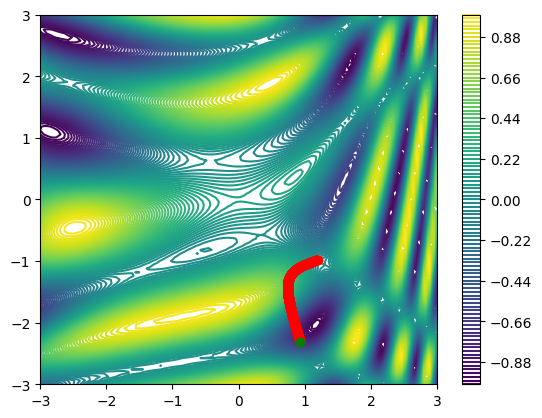

Solucion: [0.9282948743984586, -2.306032921929055] -0.7994669750735607


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

resolucion = 100
rango = 3

# Rango de valores para X y Y
X = np.linspace(-rango, rango, resolucion)
Y = np.linspace(-rango, rango, resolucion)
Z = np.zeros((resolucion,resolucion))

for ix,x in enumerate(X):
  for iy,y in enumerate(Y):
    Z[ix][iy] = f([x,y])

plt.contour(X,Y,Z,resolucion)
plt.colorbar()

P = [random.uniform(-2.5,2.5),random.uniform(-2.5,2.5)]
plt.plot(P[0],P[1],"o",c="orange")

TA = .005

for _ in range(500):
  grad = df(P)
  #print(P,grad)
  P[0],P[1] = P[0] - TA*grad[0] , P[1] - TA*grad[1]
  plt.plot(P[0],P[1],"o",c="red")

#Dibujamos el punto final y pintamos de verde
plt.plot(P[0],P[1],"o",c="green")
plt.show()
print("Solucion:" , P , f(P))

##Problema de Autobuses por Fuerza Bruta

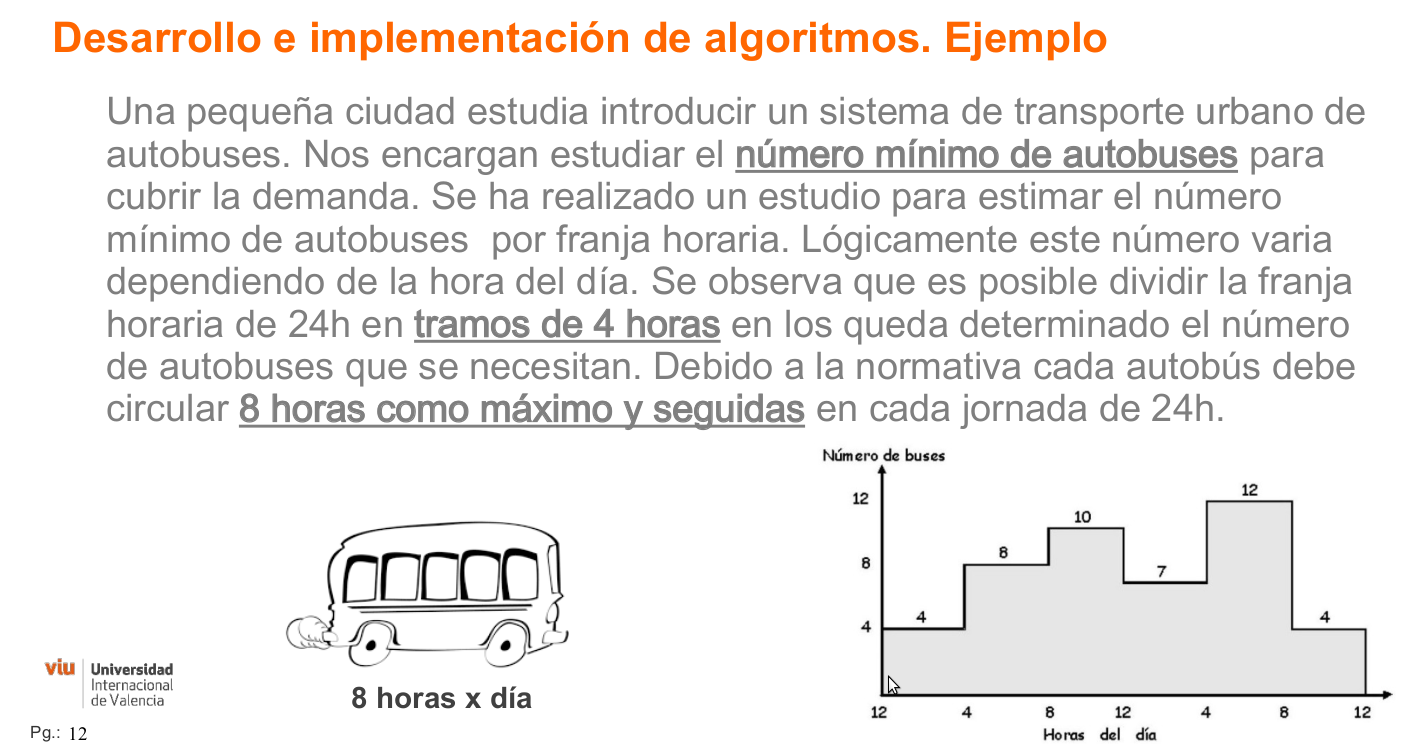

In [ ]:
###################################################
# Ximo Sanz Tornero.
###################################################
from itertools import product

# Paso 1: Inicializamos los datos
# Demanda mínima de autobuses por tramo
demanda = [4, 8, 10, 7, 12, 4]  # d[0], d[1], ..., d[5]
tramos = len(demanda)  # Número de tramos (6 en este caso)


#Posible Solucion
x = [4,5,6,7,8,9]

for t in range(tramos):
    # Calculamos el número actual de autobuses que están cubriendo el tramo t
    cobertura_actual = x[t] + x[t - 1]  # Autobuses en t y t-1 (cíclico)

    # Si la cobertura actual es menor que la demanda, añadimos autobuses en t
    if cobertura_actual < demanda[t]:
        # Añadimos los autobuses necesarios en el tramo t
        x[t] += demanda[t] - cobertura_actual

#Función objetivo
f_objetivo = sum(x)


# Se crean funciones tanto para verificar posibles soluciones como para obtener el valor de la función objetivo de la solución
# Función objetivo: suma de todos los x[i]
def funcion_objetivo(solucion):
    return sum(solucion)

# Verificación de restricciones
def verifica_restricciones(solucion):
    for t in range(tramos):
        # Se calcula el número actual de autobuses que están cubriendo el tramo t
        cobertura_actual = solucion[t] + solucion[t - 1]  # Cíclico
        if cobertura_actual < demanda[t]:
            return False
    return True


# Se realiza el algoritmo por fuerza bruta con todas las posibles combinaciones de valores que tenemos en funcion de la variable demanda
# Generación del espacio de soluciones
# Para ver mejor el funcionamiento, ejecutar: for solucion in product(*(range(d + 1) for d in [1,2,3])):   print(solucion)
espacio_soluciones = product(*(range(d + 1) for d in demanda))

# Búsqueda de la mejor solución
mejor_valor_objetivo = float('inf')
mejores_soluciones = []

for solucion in espacio_soluciones:
    if verifica_restricciones(solucion):
        valor_objetivo = funcion_objetivo(solucion)
        if valor_objetivo < mejor_valor_objetivo:
            mejor_valor_objetivo = valor_objetivo
            mejores_soluciones = [solucion]
        elif valor_objetivo == mejor_valor_objetivo:
            mejores_soluciones.append(solucion)  # Agrega soluciones con el mismo valor

# Resultado
print("Mejores soluciones:")
for solucion in mejores_soluciones:
    print(solucion)
print("Valor mínimo de la función objetivo:", mejor_valor_objetivo)



Mejores soluciones:
(0, 8, 2, 5, 7, 4)
(0, 8, 2, 6, 6, 4)
(0, 8, 2, 7, 5, 4)
(1, 7, 3, 4, 8, 3)
(1, 7, 3, 5, 7, 3)
(1, 7, 3, 6, 6, 3)
(1, 7, 3, 7, 5, 3)
(1, 8, 2, 5, 7, 3)
(1, 8, 2, 6, 6, 3)
(1, 8, 2, 7, 5, 3)
(2, 6, 4, 3, 9, 2)
(2, 6, 4, 4, 8, 2)
(2, 6, 4, 5, 7, 2)
(2, 6, 4, 6, 6, 2)
(2, 6, 4, 7, 5, 2)
(2, 7, 3, 4, 8, 2)
(2, 7, 3, 5, 7, 2)
(2, 7, 3, 6, 6, 2)
(2, 7, 3, 7, 5, 2)
(2, 8, 2, 5, 7, 2)
(2, 8, 2, 6, 6, 2)
(2, 8, 2, 7, 5, 2)
(3, 5, 5, 2, 10, 1)
(3, 5, 5, 3, 9, 1)
(3, 5, 5, 4, 8, 1)
(3, 5, 5, 5, 7, 1)
(3, 5, 5, 6, 6, 1)
(3, 5, 5, 7, 5, 1)
(3, 6, 4, 3, 9, 1)
(3, 6, 4, 4, 8, 1)
(3, 6, 4, 5, 7, 1)
(3, 6, 4, 6, 6, 1)
(3, 6, 4, 7, 5, 1)
(3, 7, 3, 4, 8, 1)
(3, 7, 3, 5, 7, 1)
(3, 7, 3, 6, 6, 1)
(3, 7, 3, 7, 5, 1)
(3, 8, 2, 5, 7, 1)
(3, 8, 2, 6, 6, 1)
(3, 8, 2, 7, 5, 1)
(4, 4, 6, 1, 11, 0)
(4, 4, 6, 2, 10, 0)
(4, 4, 6, 3, 9, 0)
(4, 4, 6, 4, 8, 0)
(4, 4, 6, 5, 7, 0)
(4, 4, 6, 6, 6, 0)
(4, 4, 6, 7, 5, 0)
(4, 5, 5, 2, 10, 0)
(4, 5, 5, 3, 9, 0)
(4, 5, 5, 4, 8, 0)
(4, 5, 5, 5, 7, 0)
(4, 5, 

In [ ]:
for solucion in product(*(range(d + 1) for d in [1,2,3])):   print(solucion)

(0, 0, 0)
(0, 0, 1)
(0, 0, 2)
(0, 0, 3)
(0, 1, 0)
(0, 1, 1)
(0, 1, 2)
(0, 1, 3)
(0, 2, 0)
(0, 2, 1)
(0, 2, 2)
(0, 2, 3)
(1, 0, 0)
(1, 0, 1)
(1, 0, 2)
(1, 0, 3)
(1, 1, 0)
(1, 1, 1)
(1, 1, 2)
(1, 1, 3)
(1, 2, 0)
(1, 2, 1)
(1, 2, 2)
(1, 2, 3)
